**Hands-On Lab: Comparing Clustering Methods**          
● Step 1: Run DBSCAN on the Day 1 dataset and report how many clusters and noise points it found.       
● Step 2: Build a hierarchical clustering dendrogram and choose a cut height, noting the resulting cluster count.       
● Step 3: Compare the K-Means, DBSCAN, and hierarchical results on the same data.       
● Step 4: In Markdown, state which method best fits this dataset's shape and why.       

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from scipy.cluster.hierarchy import dendrogram, linkage 
# import scipy.cluster.hierarchy as shc

from sklearn.cluster import KMeans , DBSCAN , AgglomerativeClustering

from sklearn.metrics import silhouette_score
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid


#### Prepare Data:

In [ ]:
# load california housing as a dataframe (df)
housing = fetch_california_housing(as_frame= True)

df = housing.frame

df.head(4)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413


In [8]:
# Use  Latitude Longitude for X 
lat_long = df [['Latitude','Longitude']] # subset of the dataframe

lat, longg = df.Latitude , df.Longitude # seperate the subset into different variables 

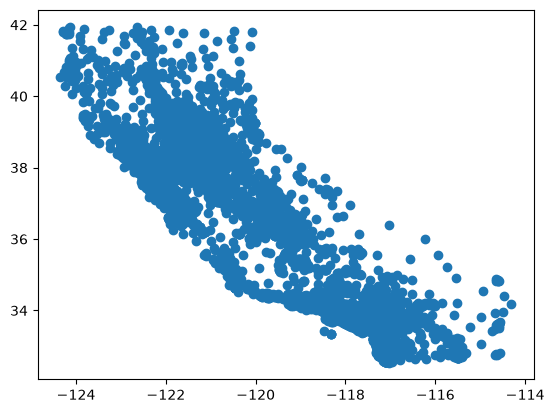

In [10]:
plt.scatter(longg, lat)

In [ ]:
# define X 
X = lat_long.to_numpy() 
X.shape

(20640, 2)

#### Train Dbscan: 

In [56]:
# eps :How close two points must be to count as neighbors.
# min_samples: How many neighbors a point needs to start a dense cluster.
# DBSCAN(eps=0.5, min_samples=5) 

db = DBSCAN(eps=0.2, min_samples=15) # left as defualt right now  

dbscan_cluster_model = db.fit(X) 

print (dbscan_cluster_model.labels_) # .label_ : gives clusters 

[0 0 0 ... 0 0 0]


In [57]:
df['cluster'] = dbscan_cluster_model.labels_ # add it as a cloumn to help with visualizaing later.
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,cluster,optimized clusters
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0,0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0,0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0,0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0,0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0,0
...,...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,0,0
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,0,0
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,0,0
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,0,0


cluster
 6    11249
 0     8545
-1      443
 2      109
 1       98
 3       98
 5       27
 7       22
 8       18
 9       16
 4       15
Name: count, dtype: int64


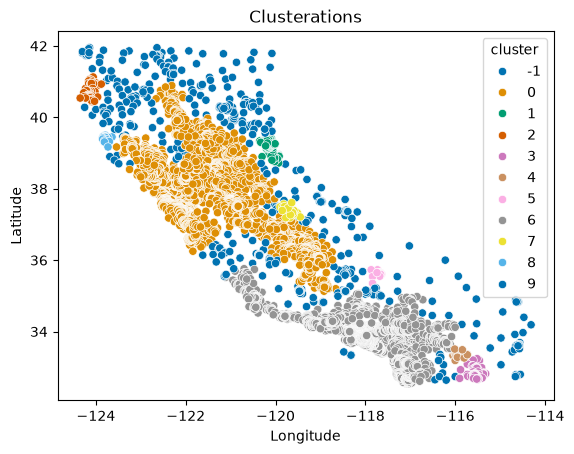

In [58]:
print(df.cluster.value_counts())

ax = sns.scatterplot(x= longg , y= lat , hue= df['cluster'], palette='colorblind')
ax.set_title('Clusterations')
plt.show()

Already from the `value counts` we can see that the model isnt doing too good. 

- To get a quantified measurement we can use silhouette_score.

In [34]:
ss = silhouette_score(X, df['cluster'])
print(f"silhouette score: {ss:.4f}")

silhouette score: 0.1103


#### Dbscan Optimization:

The previous results werent satisfing, so we'll try Gridsearchcv for it.    
but since it's different from supervised learning, we have to write it manually or in a different way.  

##### Manual Grid Search using `ParameterGrid`

To iterate through all the "combinations" of your parameters as individual dictionaries, you need to wrap param_grid in ParameterGrid.

ParameterGrid() calculates the Cartesian product (every possible pairing\combination).  
it makes the combinations instead of taking ('eps' and 'min_samples') keys as pairs.    


** only works on dictionaries (mappings).   
it is a way of doing dictionary unpacking.  
When you put ** in front of a dictionary inside a function call,    
Python takes all the key-value pairs inside that dictionary and 
turns them into standard keyword arguments. 


In [ ]:
# at first make sure that the data is scaled 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Define hyperparameter grid
param_grid = {
    'eps':[0.01, 0.03, 0.05, 0.07, 1.0], # or we can use np.linespace(.01 , 1.0, 10) or such a thing
    'min_samples': [ 3, 5 ,10 ,15],     # or we can use np.arrange(2, 20, step= 3) or such a thing
    'metric': ['euclidean','manhattan']
    }

best_score = -1 
best_params = None
best_model = None

# 2. Iterate through all combinations
for params in ParameterGrid(param_grid):
    
    dbscan = DBSCAN(**params) 
    labels = dbscan.fit_predict(X_scaled) # clusters
    
    # Check if we have at least 2 clusters (excluding noise (-1) )
    unique_labels = set(labels) - {-1} # gives the set of unique clusters (igonres the noise )
    
    if len(unique_labels) >= 2 : # checks of we have at least 2 clusters
        
         # Ignore noise when calculating silhouette (improves the result of silouette score)
        mask = labels != -1
        
        score = silhouette_score(X_scaled[mask], labels[mask])      # Then, calculate silhouette score

        if score > best_score:
            best_score =  score
            best_params = params
            best_model = dbscan
        
print(f"Best Parameters: {best_params}")
print(f"Best Silhouette Score: {best_score:.4f}")

Best Parameters: {'eps': 0.05, 'metric': 'manhattan', 'min_samples': 15}
Best Silhouette Score: 0.3675


##### inspecting best parameters resulting from the `manual Gridsearch`:

In [59]:
best_dbscan = DBSCAN(**best_params)

best_labels = best_dbscan.fit_predict(X_scaled)

df['optimized clusters'] = best_labels

print(df['optimized clusters'].value_counts())

optimized clusters
 12    10459
 0      6594
-1       880
 4       816
 20      249
 2       244
 7       235
 21      162
 16      125
 5       107
 13      104
 23      101
 3        96
 6        90
 11       79
 25       53
 24       37
 15       33
 9        25
 10       24
 17       24
 19       19
 22       19
 1        18
 8        17
 14       15
 18       15
Name: count, dtype: int64


- we expect a slight improvement from the defualt and random hyperparameters selected by hand.   
nonetheless,
- we shouldnt expect a huge improvement since it depends on the nature of data & how clustring works.   

before optimization, silhouette score: 0.1103       

After optimization(gridsearch), Best Silhouette Score: 0.3675


#### hierarchical clustering

##### Prepare data sample:
california housing data has 20,640 rows and it would be too big to make a dendrogram tree, so i'll bbe taking a sample of 1000. 

In [63]:
np.random.seed(42)

sample_indecies = np.random.choice(X_scaled.shape[0], size = 1000, replace = False) 

# X_scaled.shape[0] gives 20640 (the rows without the features). X_scaled.shape gives (20640,2) 
# becuase of replace = false, same row cannot be selected twice.

X_sample = X_scaled[sample_indecies]

print (X_sample.shape)

(1000, 2)


##### Building the dendrogram Using sample of 1000:

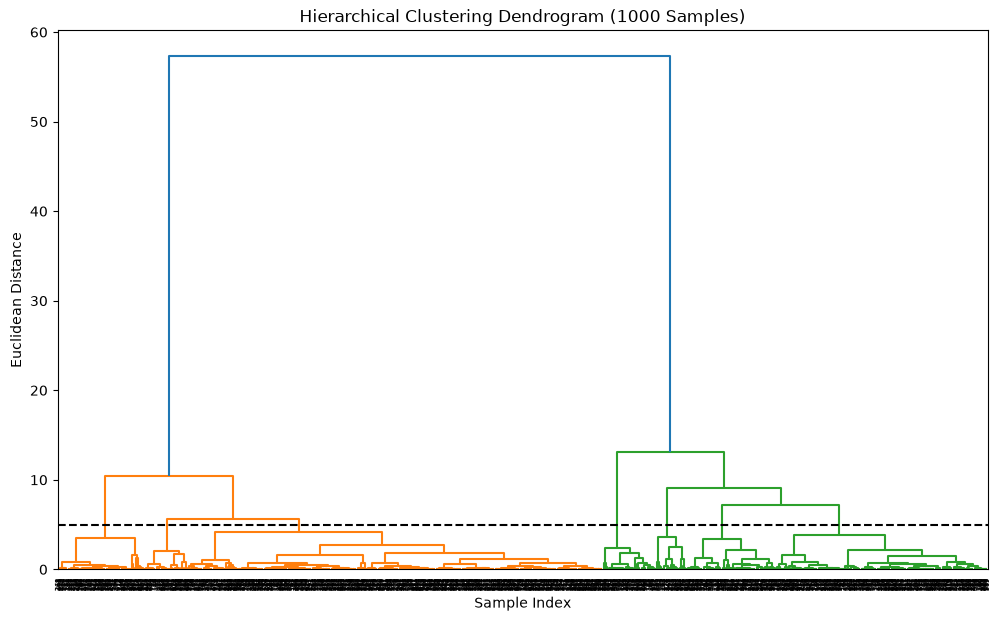

In [68]:
plt.figure(figsize=(12, 7))

Z = linkage(X_sample, method='ward')
dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram (1000 Samples)")

plt.xlabel("Sample Index")
plt.ylabel("Euclidean Distance")

# horizontal line to represent the "cut"
cut_height = 5 
plt.axhline(y=cut_height, color='black', linestyle='--')

plt.show()

**Using a Sample of 1000; The dashed line crosses 7 vertical lines, that means cutting at a height of 5 gives  7 clusters.**

##### Building the dendrogram Using Full Data:

- i used the full data just to see what it would look like 

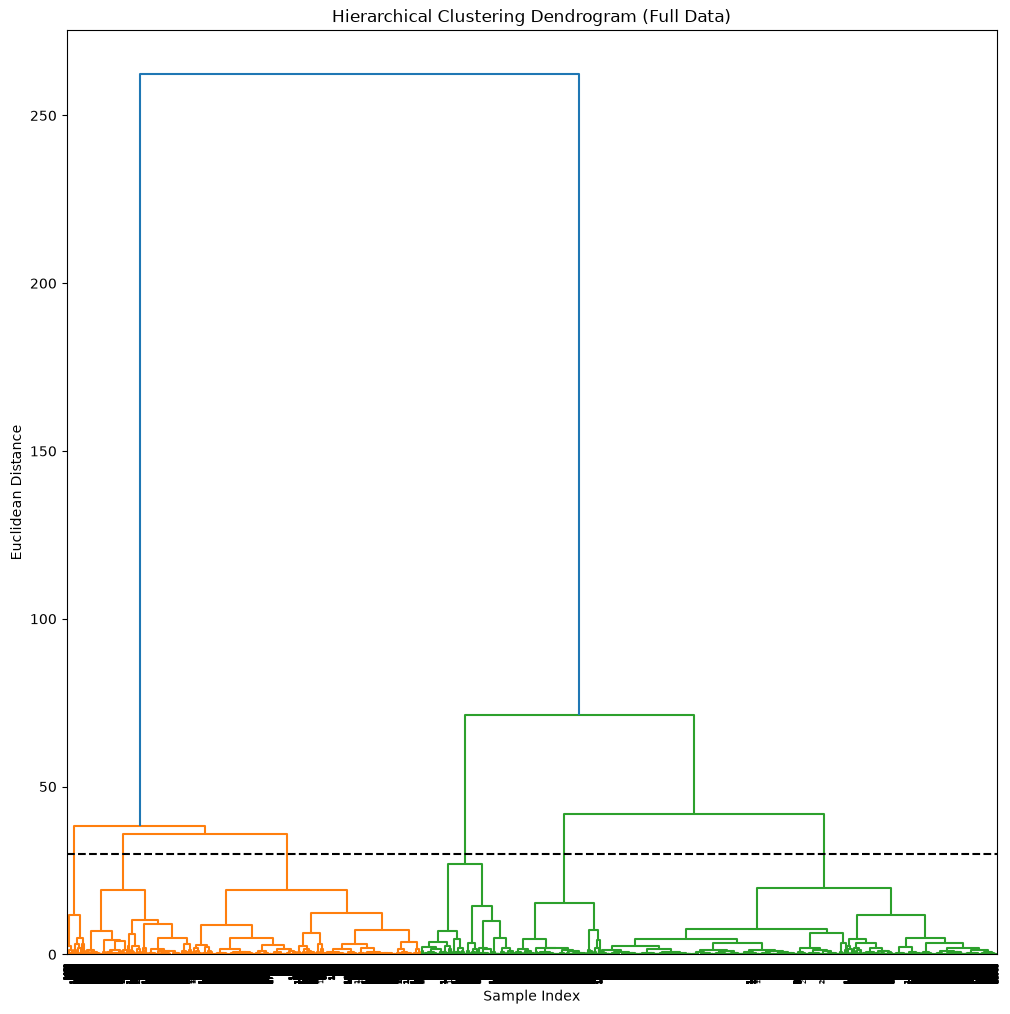

In [71]:
plt.figure(figsize=(12, 12))

Z = linkage(X_scaled, method='ward')
dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram (Full Data)")

plt.xlabel("Sample Index")
plt.ylabel("Euclidean Distance")

# horizontal line to represent the "cut"
cut_height = 30
plt.axhline(y=cut_height, color='black', linestyle='--')

plt.show()

**Using The full data; The dashed line crosses 6 vertical lines, that means cutting at a height of 30 gives 6 clusters.**

#### Comparing  K-Means, DBSCAN, and hierarchical :

- using X_scaled made in `Dbscan optimization`

 Dbscan's  silhouette_score is already found from dbscan optimizaton section.


In [ ]:
#k-means
kmeans = KMeans(n_clusters=4, random_state=42) # n_clusters=4 based on results from yesterday
kmeans_labels = kmeans.fit_predict(X_scaled)

# Hierarchical
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

# silhouette scores

kmeans_score = silhouette_score(X_scaled, kmeans_labels)

hc_score = silhouette_score(X_scaled, hc_labels)


print("Silhouette Score Comparison ")
print(f"K-Means:       {kmeans_score:.4f}")
print(f"Hierarchical:  {hc_score:.4f}")

print(f"DBSCAN:        {best_score:.4f}")

Silhouette Score Comparison 
K-Means:       0.6248
Hierarchical:  0.6332
DBSCAN:        0.3675


##### Visualization :

Text(0, 0.5, 'Latitude')

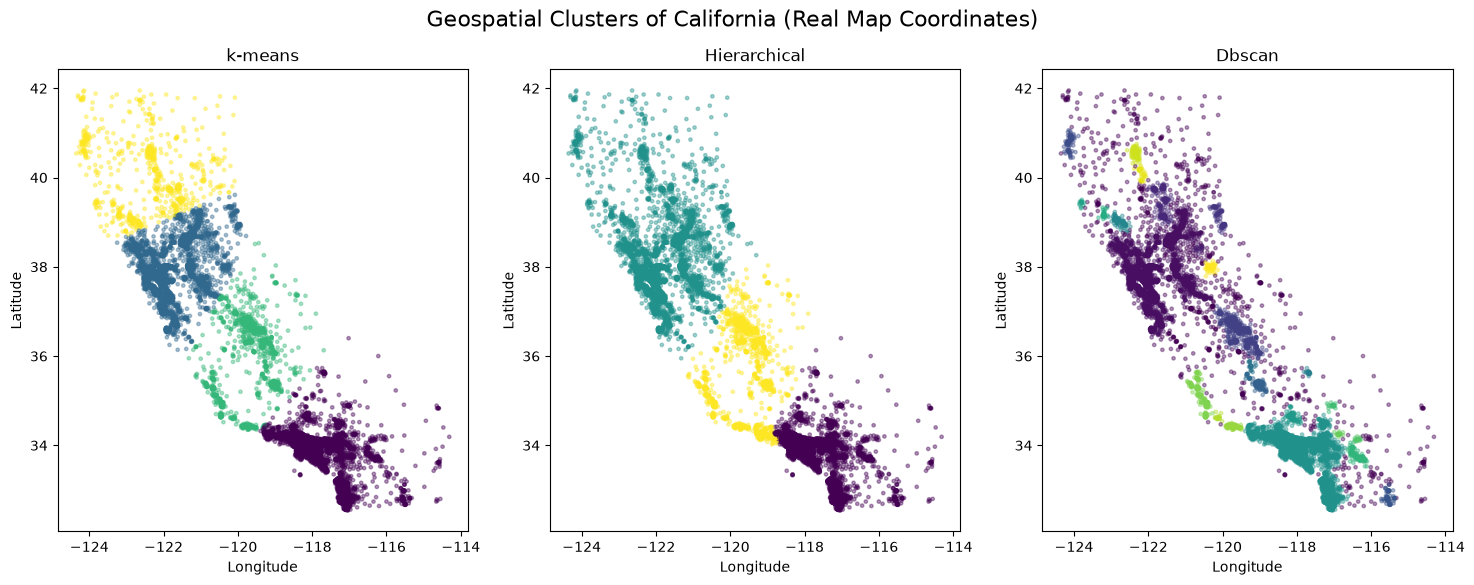

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Geospatial Clusters of California (Real Map Coordinates)", fontsize=16)

#k means
axes[0].scatter(longg, lat, c=kmeans_labels, cmap='viridis',s=6 , alpha=0.4)
axes[0].set_title('k-means')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

#hierachical
axes[1].scatter(longg, lat, c=hc_labels , cmap='viridis',  s=6 , alpha=0.4)
axes[1].set_title('Hierarchical')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

#dbscan
axes[2].scatter(longg, lat, c= df['optimized clusters'] , cmap='viridis',  s=6 , alpha=0.4)
axes[2].set_title('Dbscan')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')

### 🗺️ Geospatial Clustering Analysis (Latitude & Longitude)

| Algorithm | Silhouette Score | Geographic Interpretation |
| :--- | :---: | :--- |
| **Hierarchical (Ward)** | **0.6332** | Drew clean, balanced regional borders |
| **K-Means** | **0.6248** | Sliced the state into neat, spherical territories |
| **DBSCAN** | **0.3675** | Identified dense cities, but struggled with rural noise |

---

### Key Takeaways:

* **Why K-Means & Hierarchical Scored High:**   

  These algorithms force every data point into a cluster.   
   On a map, they effectively divide California into distinct, geometric regions.    
    Because these geographic chunks are relatively compact and round, the Silhouette Score mathematically rewards them. 

* **Why DBSCAN Scored Lower:**   

  * **The Noise Penalty:**  
   California housing is heavily concentrated in urban centers (LA, SF) with sparse housing everywhere else.    
   DBSCAN likely accurately identified the dense cities as clusters and labeled the rural/desert areas as noise (`-1`). 
    The Silhouette metric severely penalizes noise points.  

  * **Shape Bias:** 
   Cities are not perfect circles; they stretch along coastlines and highways. 
   The Silhouette score expects round clusters, meaning DBSCAN gets a low score even if it perfectly maps the actual footprint.     

**Conclusion:** 
 K-Means and Hierarchical are best here for creating broad, regional territories.   
  DBSCAN's low score is a flaw in the Silhouette metric's preference for circles, not necessarily a failure of the algorithm to find real cities.   